<a href="https://colab.research.google.com/github/indahkhairunnisah-afk/Praktikum-Pemodelan-Simulasi-dan-Optimasi/blob/main/UTS_PSO%20(.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import data ke dalam Google Colab. Ganti
nama variabel menjadi Y, X1, X2, X3 dan X4

In [85]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [86]:
# Membaca data CSV
data = pd.read_csv('/content/data soal UTS.xlsx - Sheet1.csv')
# Melihat 5 data pertama
print(data.head())

  IPM (Y)  Mayoritas Lulusan (X1) Harapan Lama Sekolah (X2) APS (X3) AHH (X4)
0   71,28                       0                     12,53     56,9    71,11
1    73,8                       1                     13,62     71,4    69,55
2   70,25                       0                        13    71,43    67,85
3   73,64                       0                     13,43    74,53    68,84
4   75,11                       1                     13,87    79,24    71,34


In [87]:
data.rename(columns={'IPM (Y)': 'Y', 'Mayoritas Lulusan (X1)': 'X1', 'Harapan Lama Sekolah (X2)': 'X2', 'APS (X3)': 'X3', 'AHH (X4)': 'X4',}, inplace=True)
print(data)

        Y  X1     X2     X3     X4
0   71,28   0  12,53   56,9  71,11
1    73,8   1  13,62   71,4  69,55
2   70,25   0     13  71,43  67,85
3   73,64   0  13,43  74,53  68,84
4   75,11   1  13,87  79,24  71,34
5   73,01   0   13,7  68,96  70,89
6   68,95   0  12,12  70,64  66,99
7   71,13   0  12,69  65,24  69,04
8   84,85   1  15,61  71,19   72,6
9   80,77   1  15,12  84,45  71,39
10  80,36   1  14,54  71,53  71,78
11  73,23   1  13,41  70,57     71


2. Lakukan pemodelan regresi berganda dengan Y sebagai variabel dependen, interpretasikan
hasil pemodelan

In [90]:
data = data.replace (',','.', regex=True)
data = data.astype(float)

In [92]:
# Menghitung matriks korelasi
correlation_matrix = data.corr()
print(correlation_matrix)

           Y        X1        X2        X3        X4
Y   1.000000  0.718702  0.967662  0.445121  0.775414
X1  0.718702  1.000000  0.728356  0.526760  0.656652
X2  0.967662  0.728356  1.000000  0.563129  0.754743
X3  0.445121  0.526760  0.563129  1.000000  0.109467
X4  0.775414  0.656652  0.754743  0.109467  1.000000


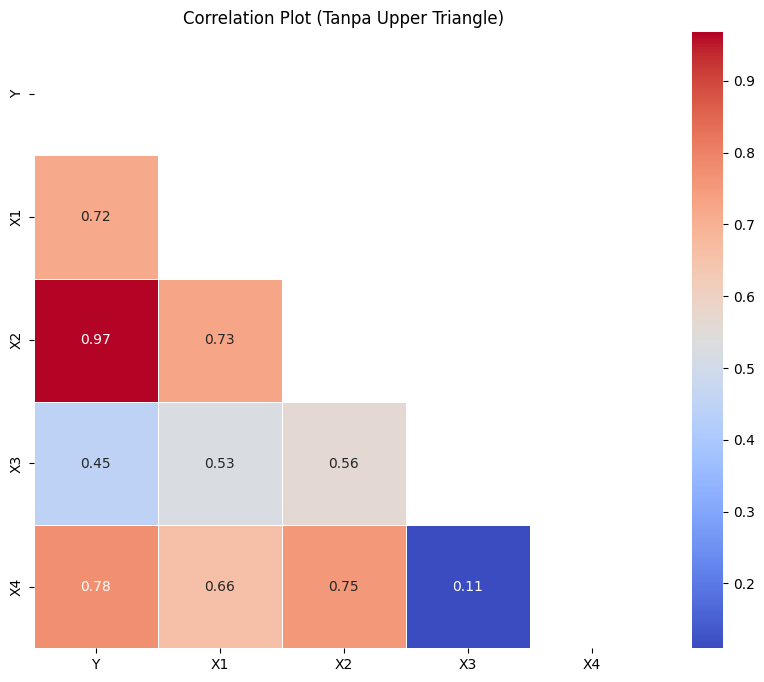

In [93]:
# Membuat mask untuk upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Membuat heatmap tanpa upper triangle
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Plot (Tanpa Upper Triangle)')
plt.show()

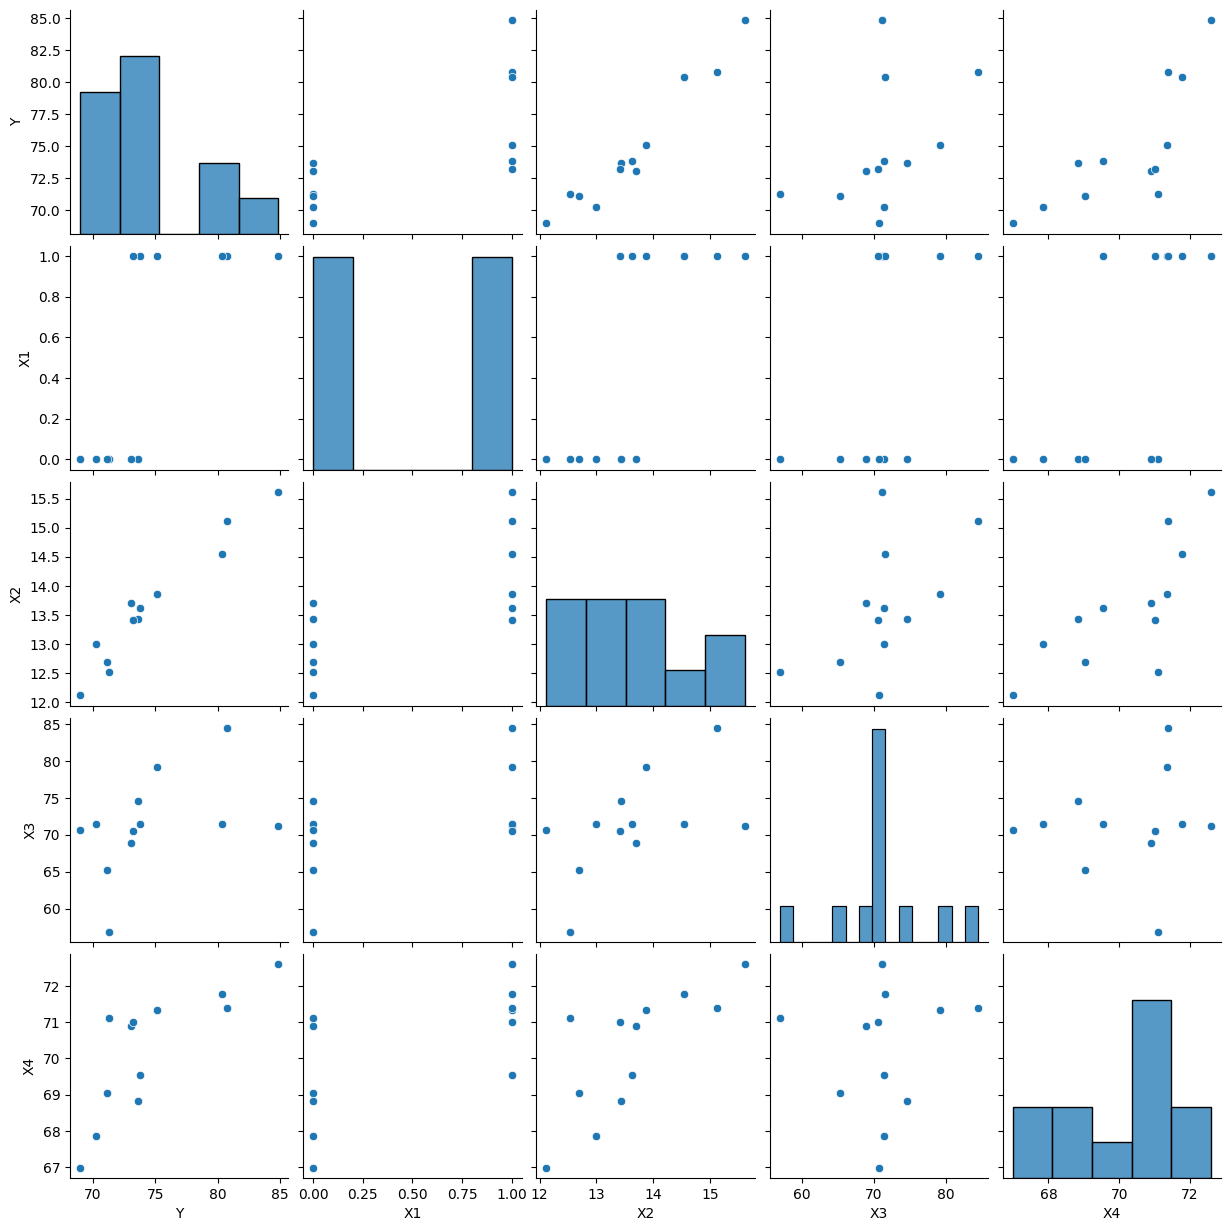

In [94]:
sns.pairplot(data)
plt.show()

In [95]:
data.describe()

,Y,X1,X2,X3,X4
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,74.698333,0.500000,13.636667,71.340000,70.198333
std,4.827271,0.522233,1.039653,6.721738,1.715188
min,68.950000,0.000000,12.120000,56.900000,66.990000
25%,71.242500,0.000000,12.922500,70.167500,68.990000
50%,73.435000,0.500000,13.525000,71.295000,70.945000
75%,76.422500,1.000000,14.037500,72.280000,71.352500
max,84.850000,1.000000,15.610000,84.450000,72.600000


In [97]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = data[['X1','X2','X3','X4']] # Variabel independen
Y = data['Y']  # Variabel dependen

In [99]:
print(X)

     X1     X2     X3     X4
0   0.0  12.53  56.90  71.11
1   1.0  13.62  71.40  69.55
2   0.0  13.00  71.43  67.85
3   0.0  13.43  74.53  68.84
4   1.0  13.87  79.24  71.34
5   0.0  13.70  68.96  70.89
6   0.0  12.12  70.64  66.99
7   0.0  12.69  65.24  69.04
8   1.0  15.61  71.19  72.60
9   1.0  15.12  84.45  71.39
10  1.0  14.54  71.53  71.78
11  1.0  13.41  70.57  71.00


In [100]:
print(Y)

0     71.28
1     73.80
2     70.25
3     73.64
4     75.11
5     73.01
6     68.95
7     71.13
8     84.85
9     80.77
10    80.36
11    73.23
Name: Y, dtype: float64


In [101]:
#ubah X dan Y menjadi bentuk matriks
X_new = np.array(X)
y_new = np.array(Y)

In [102]:
# transpose matriks X
XT = X_new.T

# menghitung (X'X)
XTX = np.dot(XT, X_new)
print(XTX)

[[6.00000000e+00 8.61700000e+01 4.48380000e+02 4.27660000e+02]
 [8.61700000e+01 2.24339380e+03 1.17173659e+04 1.15020597e+04]
 [4.48380000e+02 1.17173659e+04 6.15697466e+04 6.01092718e+04]
 [4.27660000e+02 1.15020597e+04 6.01092718e+04 5.91660326e+04]]


In [103]:
# menghitung invers (X'X)^(-1)
XTX_inv = np.linalg.inv(XTX)
print(XTX_inv)

[[ 6.03053659e-01 -2.43119374e-01 -1.23276375e-03  4.41566223e-02]
 [-2.43119374e-01  2.85745071e-01 -1.14419495e-02 -4.21680662e-02]
 [-1.23276375e-03 -1.14419495e-02  2.75302882e-03 -5.63657324e-04]
 [ 4.41566223e-02 -4.21680662e-02 -5.63657324e-04  8.46797738e-03]]


In [104]:
# menghitung X'Y
XTY =np.dot(XT,y_new)
print(XTY)

[  468.12   12277.0556 64106.6238 62995.004 ]


In [105]:
# menghitung beta
beta = np.dot(XTX_inv,XTY)

print("Koefisien beta:")
print(beta)

Koefisien beta:
[ 0.12968644  4.41682926 -0.07074409  0.27700495]


In [106]:
# Membuat model regresi linear
model = sm.OLS(Y, X).fit()

# Melihat ringkasan model
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.011e+04
Date:                Wed, 15 Apr 2026   Prob (F-statistic):                    7.64e-15
Time:                        02:23:37   Log-Likelihood:                         -17.640
No. Observations:                  12   AIC:                                      43.28
Df Residuals:                       8   BIC:                                      45.22
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

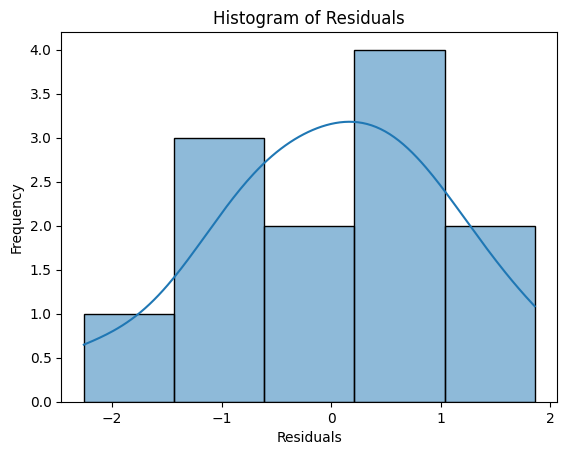

Shapiro-Wilk Test: W=0.9761451775030698, p-value=0.963460011338081


In [107]:
# Plot Histogram Residual
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test[1]}')

In [108]:
#transformasi ln
# Membuat model regresi linear
model_ln = sm.OLS(np.log(Y), X).fit()

# Melihat ringkasan model
print(model_ln.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.715e+04
Date:                Wed, 15 Apr 2026   Prob (F-statistic):                    9.25e-16
Time:                        02:24:09   Log-Likelihood:                          19.775
No. Observations:                  12   AIC:                                     -31.55
Df Residuals:                       8   BIC:                                     -29.61
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Variabel X4 terbukti berpengaruh nyata terhadap Y karena nilai p‑value = 0.000. Artinya, X4 benar-benar punya hubungan yang kuat dengan Y. Sebaliknya, variabel X1 (p = 0.116) dan X2 (p = 0.929) tidak menunjukkan pengaruh yang berarti karena nilai p‑value mereka jauh di atas batas signifikansi. Variabel X3 memiliki p‑value = 0.058, yang hampir mendekati batas signifikansi, tetapi masih belum cukup kuat untuk dianggap berpengaruh.

3. Selidiki distribusi probabilitas disetiap variabel


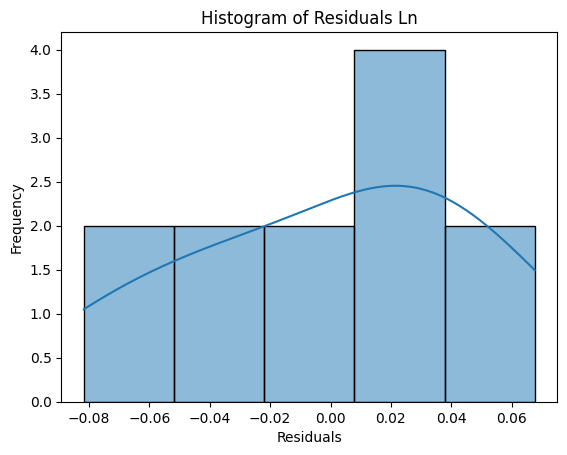

Shapiro-Wilk Test: W=0.9761451775030698, p-value=0.6209376585345456


In [114]:
# Plot Histogram Residual
residuals_ln = model_ln.resid
sns.histplot(residuals_ln, kde=True)
plt.title('Histogram of Residuals Ln')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test_ln = stats.shapiro(residuals_ln)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test_ln[1]}')

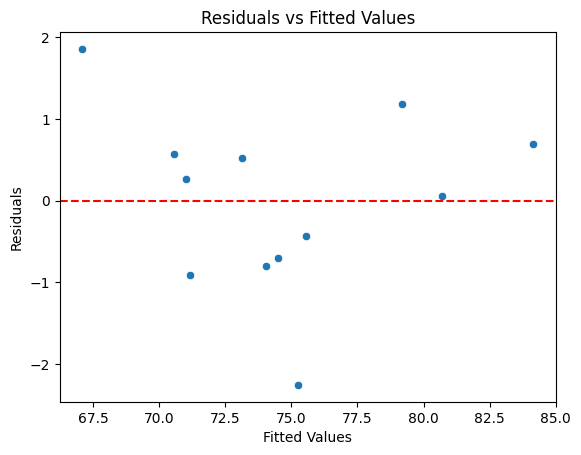

Breusch-Pagan Test: p-value=0.7571024312595305


In [112]:
# Plot Residual vs Fitted Values
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Uji Homoskedastisitas menggunakan Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

X_with_constant = sm.add_constant(X) # Add a constant to the independent variables
bp_test = het_breuschpagan(residuals, X_with_constant)
print(f'Breusch-Pagan Test: p-value={bp_test[1]}')

In [113]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson

# Melakukan Uji Breusch-Godfrey untuk Autokorelasi
dw_test = durbin_watson(residuals)
bg_test = acorr_breusch_godfrey(model, nlags=1)
p_value = bg_test[1]  # Mendapatkan p-value



print(f'Breusch-Pagan Value: {dw_test}')
print(f'Breusch-Godfrey p-value: {p_value}')

Breusch-Pagan Value: 2.3753765408734058
Breusch-Godfrey p-value: 0.19239731676037958


4. Carilah nilai parameter dari setiap distribusi probabilitas di Y, X1, X2, X3 dan X4

In [123]:
col_name = "Y"
current_variable_data = Y.dropna()

# Estimasi parameter distribusi normal
mu, sigma = stats.norm.fit(current_variable_data)

print(f"Variabel: {col_name}")
print(f"Mean (μ): {mu:.4f}")
print(f"Standar Deviasi (σ): {sigma:.4f}")
print("-")

for col_name in ["X1", "X2", "X3", "X4"]:
    current_variable_data = X[col_name].dropna()

    # Estimasi parameter distribusi normal
    mu, sigma = stats.norm.fit(current_variable_data)

    print(f"Variabel: {col_name}")
    print(f"Mean (μ): {mu:.4f}")
    print(f"Standar Deviasi (σ): {sigma:.4f}")
    print("-"*40)

Variabel: Y
Mean (μ): 74.6983
Standar Deviasi (σ): 4.6218
-
Variabel: X1
Mean (μ): 0.5000
Standar Deviasi (σ): 0.5000
----------------------------------------
Variabel: X2
Mean (μ): 13.6367
Standar Deviasi (σ): 0.9954
----------------------------------------
Variabel: X3
Mean (μ): 71.3400
Standar Deviasi (σ): 6.4356
----------------------------------------
Variabel: X4
Mean (μ): 70.1983
Standar Deviasi (σ): 1.6422
----------------------------------------


5. Simulasikan Y, X1, X2, X3 dan X4 menjadi 500 data sesuai dengan aturan (point 25

In [124]:
# Tentukan jumlah data
n = 500

# Simulasi variabel independen dari distribusi normal standar
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)
X4 = np.random.normal(0, 1, n)

# Simulasi error acak
error = np.random.normal(0, 0.1, n)

# Hitung Y sesuai persamaan regresi
Y = -0.0781*X1 + 0.0028*X2 + 0.0066*X3 + 0.0547*X4 + error

# Gabungkan ke dalam DataFrame
df = pd.DataFrame({
    "Y": Y,
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "X4": X4
})

# Tampilkan 5 data pertama
print(df.head())


          Y        X1        X2        X3        X4
0 -0.038261 -0.957683  0.968128  0.153915 -1.343683
1 -0.092077  0.364641 -0.503778 -0.249645 -0.538576
2  0.147452 -0.385484 -0.145096  0.154790  0.160599
3  0.000312 -2.005718  1.183625  1.446792 -1.316900
4  0.152527 -1.424703  1.724932 -0.635599 -1.238077


6. Modelkan data hasil simulasi dengan Y sebagai variabel dependen, dan interpretasikan (point
25).


In [125]:
X = df[["X1", "X2", "X3", "X4"]]
X = sm.add_constant(X)  # tambahkan intercept
model = sm.OLS(df["Y"], X).fit()

# Ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     124.0
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.96e-73
Time:                        02:42:54   Log-Likelihood:                 462.11
No. Observations:                 500   AIC:                            -914.2
Df Residuals:                     495   BIC:                            -893.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0020      0.004     -0.454      0.6

Model menunjukkan bahwa X1 dan X4 berpengaruh nyata terhadap Y. Nilai p‑value X1 = 0.000 dan X4 = 0.000, artinya keduanya signifikan secara statistik. X1 memiliki pengaruh negatif, sedangkan X4 berpengaruh positif.Sebaliknya, X2 (p = 0.342) dan X3 (p = 0.175) tidak signifikan, sehingga tidak terbukti memberikan pengaruh yang berarti terhadap Y.